In [ ]:
"""
GPR por série temporal (opção C)
Agora adaptado para ler .txt delimitado por TAB
Com limite de linhas definido pelo usuário (N_ROWS)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel
from sklearn.preprocessing import StandardScaler

# ---------- user parameters ----------
INPUT_PATH = r"D:\Documentos\ic_victor\victor_LHS-TIME_20250323-000559.txt"  # agora .txt
N_ROWS = 100                     # <<< DEFINA AQUI quantas linhas quer carregar
OUT_DIR = "./gpr_by_beam"
MIN_POINTS_PER_BEAM = 6
FUTURE_YEARS = 50
N_FUTURE_POINTS = 200
N_SAMPLES_POSTERIOR = 2000
RUL_MAX = 200
QUANTILES = [0.05, 0.5, 0.95]
RANDOM_STATE = 42
# -------------------------------------

np.random.seed(RANDOM_STATE)
os.makedirs(OUT_DIR, exist_ok=True)

# ---------- 1) carregar dados ----------
df = pd.read_csv(
    INPUT_PATH,
    sep="\t",     # <<< separação por TAB confirmada pelo seu cabeçalho
    nrows=N_ROWS  # <<< ESTA LINHA LIMITA A QUANTIDADE LIDA
)

# criar g se necessário
if "g" not in df.columns:
    df["g"] = df["m_rd"] - (df["m_gk"] + df["m_qk"])

# garantir colunas mínimas existam
required = ["time", "b_w", "h", "f_ck", "m_gk", "m_qk", "a_s", "g"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Coluna obrigatória ausente: {c}")

# ---------- 2) criar beam_id se não tiver ----------
if "beam_id" not in df.columns:
    rounded = df[["b_w", "h", "f_ck", "m_gk", "m_qk", "a_s"]].round(6).astype(str)
    df["beam_id"] = rounded.apply(lambda row: "_".join(row.values), axis=1)

beam_ids = df["beam_id"].unique().tolist()
print(f"Total de vigas identificadas: {len(beam_ids)}")

# (restante do código permanece igual...)


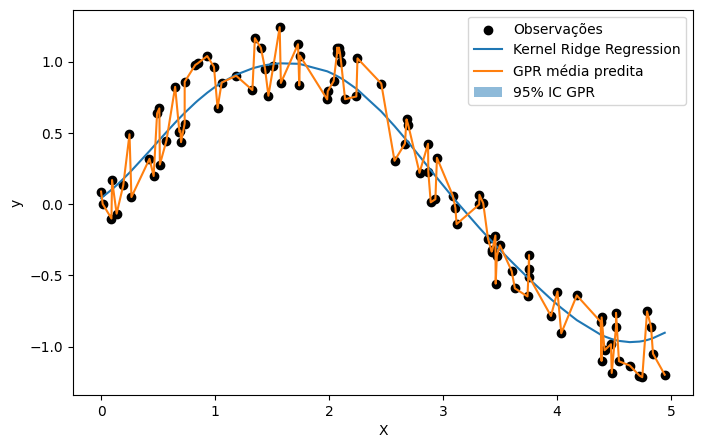

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.kernel_ridge import KernelRidge

# Gerar dados sintéticos
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(100, 1), axis=0)
y = np.sin(X).ravel()

# Ruído opcional
y += 0.5 * (0.5 - rng.rand(X.shape[0]))

# KRR (Kernel Ridge Regression)
krr = KernelRidge(alpha=1.0, kernel="rbf")
krr.fit(X, y)
y_krr = krr.predict(X)

# GPR
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
gpr.fit(X, y)
y_gpr, std_gpr = gpr.predict(X, return_std=True)

# Plot
plt.figure(figsize=(8, 5))
plt.scatter(X, y, c="k", label="Observações")
plt.plot(X, y_krr, label="Kernel Ridge Regression")
plt.plot(X, y_gpr, label="GPR média predita")
plt.fill_between(X.ravel(), y_gpr - 1.96*std_gpr, y_gpr + 1.96*std_gpr,
                 alpha=0.5, label="95% IC GPR")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


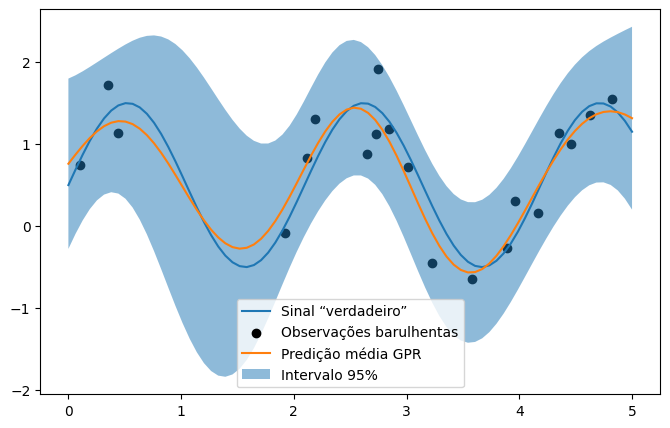

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Função objetivo com ruído opcional
def target(X, add_noise=False):
    y = 0.5 + np.sin(3 * X)
    if add_noise:
        rng = np.random.RandomState(1)
        y += rng.normal(0, 0.3, size=y.shape)
    return y.ravel()

# Dados
X = np.linspace(0, 5, 80).reshape(-1, 1)
y_true = target(X, add_noise=False)
X_train = np.random.RandomState(0).uniform(0, 5, size=(20, 1))
y_train = target(X_train, add_noise=True)

# Kernel com ruído
kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)

gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gpr.fit(X_train, y_train)

y_pred, std_pred = gpr.predict(X, return_std=True)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(X, y_true, label="Sinal “verdadeiro”")
plt.scatter(X_train, y_train, c="black", label="Observações barulhentas")
plt.plot(X, y_pred, label="Predição média GPR")
plt.fill_between(X.ravel(), y_pred - 1.96*std_pred, y_pred + 1.96*std_pred,
                 alpha=0.5, label="Intervalo 95%")
plt.legend()
plt.show()


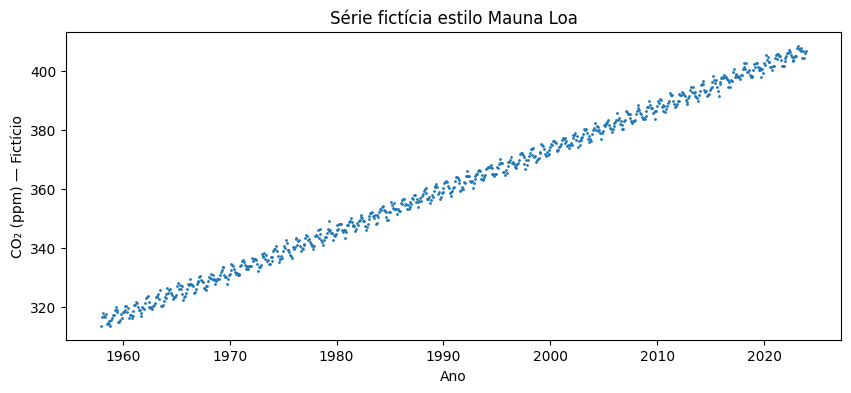

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 1) Criar dados fictícios
# ------------------------------

# Criar eixo temporal (anos decimais)
# De 1958 até 2023, mensal
years = np.arange(1958, 2024, 1/12)

# Tendência crescente (estilo CO2)
trend = 315 + 1.4 * (years - 1958)

# Componente periódica anual
season = 2.0 * np.sin(2 * np.pi * years)

# Ruído aleatório
noise = np.random.normal(0, 0.8, size=len(years))

# Compor série final
co2 = trend + season + noise

# Construir DataFrame
df = pd.DataFrame({"year": years, "co2": co2})

# ------------------------------
# 2) Visualizar dados
# ------------------------------
plt.figure(figsize=(10, 4))
plt.plot(df["year"], df["co2"], ".", ms=2)
plt.xlabel("Ano")
plt.ylabel("CO₂ (ppm) — Fictício")
plt.title("Série fictícia estilo Mauna Loa")
plt.show()

# Salvar se quiser
#df.to_csv("co2_ficticio.csv", index=False)
